# Notebook 02 — Perspective Transform (Bird's-Eye View)

In a normal camera image, parallel lanes appear to converge toward a vanishing point. This perspective foreshortening makes lane fitting harder:
- A constant-width lane appears wider near the camera and narrower far away
- A 2nd-degree polynomial fit struggles with strong perspective convergence
- Real-world distance measurements (curvature, lane width) are not directly readable

To fix this, we apply **Inverse Perspective Mapping (IPM)** — a homography that warps the image as if seen from above. After warping:
- Lanes appear roughly vertical and parallel
- Polynomial fitting is much easier and more stable
- The warped image is in a quasi-real-world coordinate system

A homography is a 3×3 matrix with 8 degrees of freedom (one is fixed by scale invariance). Solving for it requires 4 point correspondences (each provides 2 equations, total 8 equations).

This notebook does three things:
1. Define source points (a trapezoid covering the road in the camera image) and destination points (a rectangle in the bird's-eye view)
2. Compute the forward and inverse homography matrices
3. Verify the transform by warping the ground-truth lane points and checking they appear parallel

## 1. Imports and load a sample image

Same setup pattern as Notebook 01: import OpenCV, NumPy, Matplotlib, and our `TuSimpleDataset` loader. We pick `dataset[0]` as our reference image for tuning the trapezoid.

We will tune the perspective transform on **one image only**, but because the TuSimple camera position is fixed across all clips, the same transform works for every frame in the dataset.

In [1]:
"""Notebook 02: Perspective transform — turn camera view into bird's-eye view."""

import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

from tusimple_loader import TuSimpleDataset

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 100

dataset = TuSimpleDataset(
    annotation_file=project_root / "data/tusimple/test_subset/test_label_subset.json",
    image_root=project_root / "data/tusimple/test_subset",
)

# Load a sample image
sample = dataset[0]
img = cv2.imread(str(sample.image_path))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(f"Image shape: {img.shape}")  # (720, 1280, 3)
plt.imshow(img)
plt.title("Sample image — we need to identify the road region")
plt.axis("off")
plt.show()

FileNotFoundError: Annotation file not found: /workspaces/lane-detection-cv/data/tusimple/test_subset/test_label_subset.json

## 2. Define the source trapezoid

The source trapezoid is the region of the camera image that we want to warp. There is no automatic way to pick these points — they depend on the physical camera position and tilt, which is fixed for TuSimple.

The four corners go in this order (counter-clockwise from top-left):
- **Point 0**: top-left — just outside the leftmost lane near the horizon
- **Point 1**: top-right — just outside the rightmost lane near the horizon
- **Point 2**: bottom-right — near the right edge at the bottom of the image
- **Point 3**: bottom-left — near the left edge at the bottom of the image

The "top y" we pick is critical: too high (close to the actual horizon at y≈260) and the trapezoid becomes pencil-thin, making the warped result very noisy; too low (close to the bottom) and we lose the far-distance lane information that we need for the polynomial fit. A good range is y = 440 to 480.

Image is 1280 wide × 720 tall


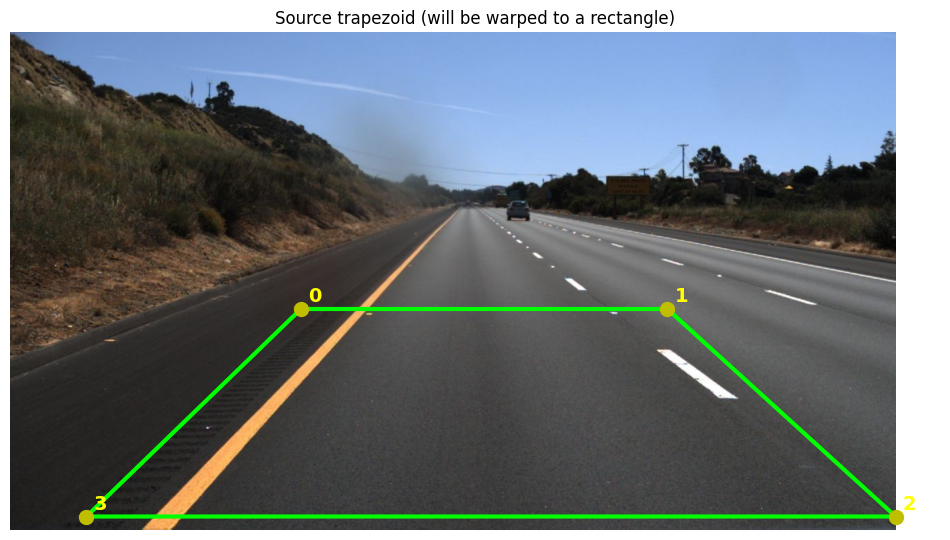

In [ ]:
H, W = img.shape[:2]  # 720, 1280
print(f"Image is {W} wide × {H} tall")

# Source points: a trapezoid covering the visible road region.
# Order: top-left, top-right, bottom-right, bottom-left
#
# How to pick these:
# - Top y (~y=460): just below the horizon, where lanes are still discernible.
#   Going higher → too narrow, lots of noise from sky/distant cars.
# - Bottom y (~y=720): bottom of the image (we want the full near-field road).
# - Top-left x and top-right x: just outside the leftmost and rightmost lanes
#   where they appear at the top y (so the trapezoid encloses all lanes).
# - Bottom-left x and bottom-right x: where those lanes meet the image bottom,
#   typically very near the image edges.

src_pts = np.float32([
    [420,  400],   # top-left
    [950,  400],   # top-right
    [1280, 700],   # bottom-right
    [110,  700],   # bottom-left
])

# Destination points: a rectangle in the output image.
# We pick a 720x720 output where the road takes up the full width.
DST_W, DST_H = 720, 720
dst_pts = np.float32([
    [0,     0],       # top-left
    [DST_W, 0],       # top-right
    [DST_W, DST_H],   # bottom-right
    [0,     DST_H],   # bottom-left
])

# Visualize the source trapezoid on the original image
fig, ax = plt.subplots()
ax.imshow(img)
trap = MplPolygon(src_pts, closed=True, fill=False,
                  edgecolor="lime", linewidth=3)
ax.add_patch(trap)
for i, (x, y) in enumerate(src_pts):
    ax.plot(x, y, "yo", markersize=10)
    ax.annotate(f"{i}", (x, y), color="yellow",
                fontsize=14, fontweight="bold", xytext=(5, 5),
                textcoords="offset points")
ax.set_title("Source trapezoid (will be warped to a rectangle)")
ax.axis("off")
plt.show()

## 2.5. Interactive tuning (recommended)

Hardcoded numbers rarely work first try. This cell exposes 6 sliders so we can adjust the trapezoid corners while watching the result update in real time. Move the sliders until the orange lane lines in the right panel look as vertical and parallel as possible.

Once you find good values, **write them down** — we will hardcode them as the final source points and use them for the rest of the project.

(If `ipywidgets` is not installed, run `pip install ipywidgets` in a terminal and restart the kernel.)

In [ ]:
from ipywidgets import interact, IntSlider


def show_warp(top_y=460, top_left_x=560, top_right_x=730,
              bottom_y=700, bottom_left_x=180, bottom_right_x=1180,
              dst_size=720):
    """Interactive perspective transform tuner.

    Adjust the sliders to find good source points for the trapezoid.
    The goal: make the lanes appear vertical and parallel in the right panel.
    """
    src = np.float32([
        [top_left_x,     top_y],
        [top_right_x,    top_y],
        [bottom_right_x, bottom_y],
        [bottom_left_x,  bottom_y],
    ])
    dst = np.float32([
        [0, 0],
        [dst_size, 0],
        [dst_size, dst_size],
        [0, dst_size],
    ])

    M_local = cv2.getPerspectiveTransform(src, dst)
    warped_local = cv2.warpPerspective(img, M_local, (dst_size, dst_size))

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Left: image with trapezoid + GT lanes
    axes[0].imshow(img)
    trap = MplPolygon(src, closed=True, fill=False,
                      edgecolor="lime", linewidth=3)
    axes[0].add_patch(trap)
    for lane_idx in range(sample.num_lanes):
        pts = sample.get_lane_points(lane_idx)
        if len(pts) > 1:
            xs, ys = zip(*pts)
            axes[0].plot(xs, ys, "-", color="orange", linewidth=2, alpha=0.7)
    axes[0].set_title("Camera view (orange = GT lanes)")
    axes[0].axis("off")

    # Right: warped + transformed GT lanes
    axes[1].imshow(warped_local)
    for lane_idx in range(sample.num_lanes):
        pts = sample.get_lane_points(lane_idx)
        if len(pts) > 1:
            warped_pts = transform_points(np.array(pts), M_local)
            mask = (
                (warped_pts[:, 0] >= 0) & (warped_pts[:, 0] < dst_size)
                & (warped_pts[:, 1] >= 0) & (warped_pts[:, 1] < dst_size)
            )
            in_frame = warped_pts[mask]
            if len(in_frame) > 1:
                axes[1].plot(in_frame[:, 0], in_frame[:, 1],
                             "-", color="orange", linewidth=2)
    axes[1].set_title("Bird's-eye view (lanes should be vertical & parallel)")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()


# ⚠️ Note: the transform_points function from Cell 4 needs to be defined first.
# If you haven't run Cell 4 yet, define it here:
def transform_points(points, M):
    pts = np.array(points, dtype=np.float32).reshape(1, -1, 2)
    return cv2.perspectiveTransform(pts, M).reshape(-1, 2)


interact(
    show_warp,
    top_y=IntSlider(min=300, max=600, step=10, value=460,
                    description="top_y", continuous_update=False),
    top_left_x=IntSlider(min=400, max=700, step=5, value=560,
                         description="top_left_x", continuous_update=False),
    top_right_x=IntSlider(min=600, max=900, step=5, value=730,
                          description="top_right_x", continuous_update=False),
    bottom_y=IntSlider(min=600, max=720, step=5, value=700,
                       description="bottom_y", continuous_update=False),
    bottom_left_x=IntSlider(min=0, max=400, step=10, value=180,
                            description="bottom_left_x", continuous_update=False),
    bottom_right_x=IntSlider(min=900, max=1280, step=10, value=1180,
                             description="bottom_right_x", continuous_update=False),
)

interactive(children=(IntSlider(value=460, continuous_update=False, description='top_y', max=600, min=300, ste…

<function __main__.show_warp(top_y=460, top_left_x=560, top_right_x=730, bottom_y=700, bottom_left_x=180, bottom_right_x=1180, dst_size=720)>

## 3. Compute the homography matrix

`cv2.getPerspectiveTransform(src, dst)` solves a small linear system to find the unique 3×3 matrix that maps the four source points exactly onto the four destination points.

We compute two matrices:
- **`M`**: forward transform, camera → bird's-eye view. Used by `cv2.warpPerspective` to make the warped image.
- **`M_inv`**: inverse transform, bird's-eye → camera. Used later to draw detections from the bird's-eye view back onto the original camera image.

`cv2.warpPerspective` uses **inverse mapping**: for each output pixel it computes which source pixel it came from and samples (with bilinear interpolation when the source coordinate is fractional). This avoids holes in the output that forward mapping would produce.

Forward transform M (camera → bird's-eye):
[[-2.22680412e+00 -2.30103093e+00  1.85567010e+03]
 [ 1.06581410e-15 -8.68453608e+00  3.47381443e+03]
 [-0.00000000e+00 -6.59793814e-03  1.00000000e+00]]

M shape: (3, 3), dtype: float64


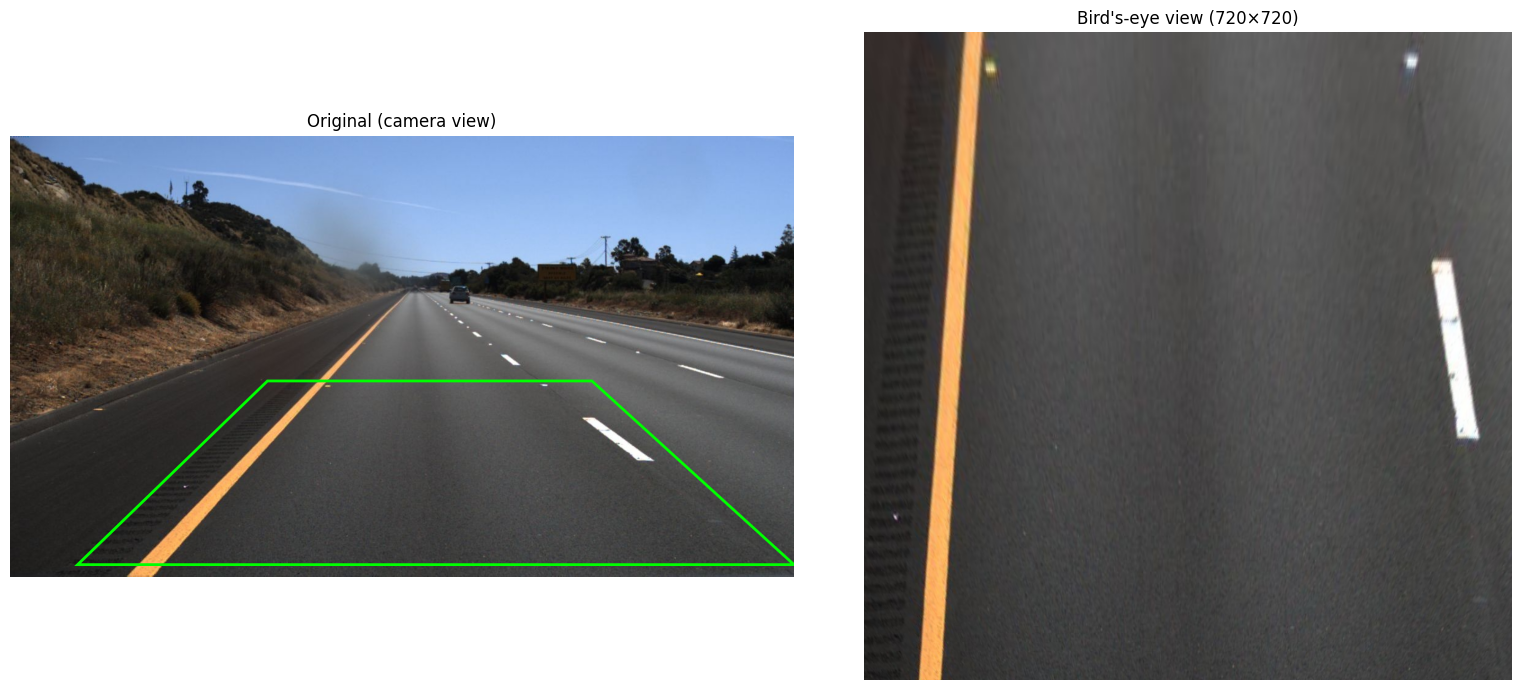

In [ ]:
# Compute the 3x3 perspective transform matrix
M = cv2.getPerspectiveTransform(src_pts, dst_pts)

# Compute the inverse (we'll need this later to map detections back to camera view)
M_inv = cv2.getPerspectiveTransform(dst_pts, src_pts)

print("Forward transform M (camera → bird's-eye):")
print(M)
print(f"\nM shape: {M.shape}, dtype: {M.dtype}")

# Apply the transform to get the bird's-eye view
warped = cv2.warpPerspective(img, M, (DST_W, DST_H), flags=cv2.INTER_LINEAR)

# Show side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(img)
axes[0].set_title("Original (camera view)")
axes[0].axis("off")
trap = MplPolygon(src_pts, closed=True, fill=False,
                  edgecolor="lime", linewidth=2)
axes[0].add_patch(trap)

axes[1].imshow(warped)
axes[1].set_title(f"Bird's-eye view ({DST_W}×{DST_H})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 4. Verify the transform with ground-truth lanes

The visual quality of the warped road is hard to judge by eye (it just looks like asphalt). The proper test is to apply the same transform `M` to the ground-truth lane points and check that the warped points are vertical and parallel.

`cv2.perspectiveTransform` applies a homography to a list of points (as opposed to `warpPerspective` which applies it to a whole image). It expects a 3-D array of shape `(1, N, 2)` and returns the same shape — we reshape before and after for convenience.

If the warped lane points look:
- **Vertical and parallel** → trapezoid is well-tuned, proceed to thresholding
- **Tilted but parallel** → camera is tilted relative to our trapezoid, can rotate later
- **Not parallel** → trapezoid is misaligned with the actual road plane, re-tune

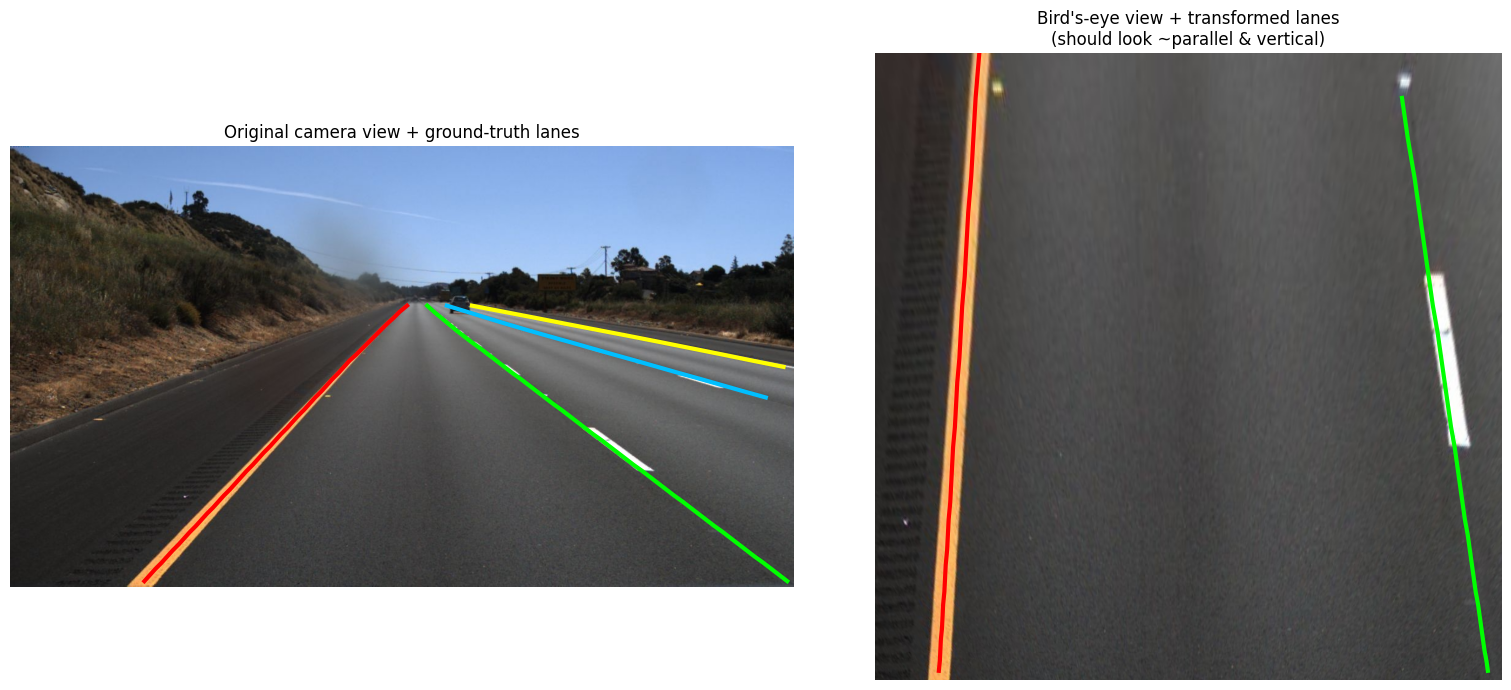

In [ ]:
# Apply transform M to the ground-truth lane points
def transform_points(points: np.ndarray, M: np.ndarray) -> np.ndarray:
    """Apply a 3x3 homography to a list of (x, y) points.

    Args:
        points: array of shape (N, 2) with [x, y] rows.
        M:      3x3 homography matrix.
    Returns:
        Transformed points of shape (N, 2).
    """
    # cv2.perspectiveTransform expects shape (1, N, 2) and float32
    pts = np.array(points, dtype=np.float32).reshape(1, -1, 2)
    transformed = cv2.perspectiveTransform(pts, M)
    return transformed.reshape(-1, 2)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: original image with GT lanes
axes[0].imshow(img)
colors = ["red", "lime", "deepskyblue", "yellow"]
for lane_idx in range(sample.num_lanes):
    pts = sample.get_lane_points(lane_idx)
    if len(pts) > 1:
        xs, ys = zip(*pts)
        axes[0].plot(xs, ys, "-", color=colors[lane_idx], linewidth=3)
axes[0].set_title("Original camera view + ground-truth lanes")
axes[0].axis("off")

# Right: warped image with transformed lanes
axes[1].imshow(warped)
for lane_idx in range(sample.num_lanes):
    pts = sample.get_lane_points(lane_idx)
    if len(pts) > 1:
        warped_pts = transform_points(np.array(pts), M)
        # Filter out points that warped outside the output frame
        mask = (
            (warped_pts[:, 0] >= 0) & (warped_pts[:, 0] < DST_W)
            & (warped_pts[:, 1] >= 0) & (warped_pts[:, 1] < DST_H)
        )
        in_frame = warped_pts[mask]
        if len(in_frame) > 1:
            axes[1].plot(in_frame[:, 0], in_frame[:, 1],
                         "-", color=colors[lane_idx], linewidth=3)

axes[1].set_title(
    "Bird's-eye view + transformed lanes\n(should look ~parallel & vertical)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 5. Validate the transform on multiple samples

A perspective transform tuned on one image must generalize to all frames. Since the TuSimple camera position is fixed, the same `M` should work everywhere — but car pitch changes slightly with road surface, and we want to confirm the lanes remain reasonably parallel across different scenes.

We pick 6 diverse samples and warp them with our chosen `SRC_PTS`. The ground-truth lanes should appear vertical and parallel in all of them.

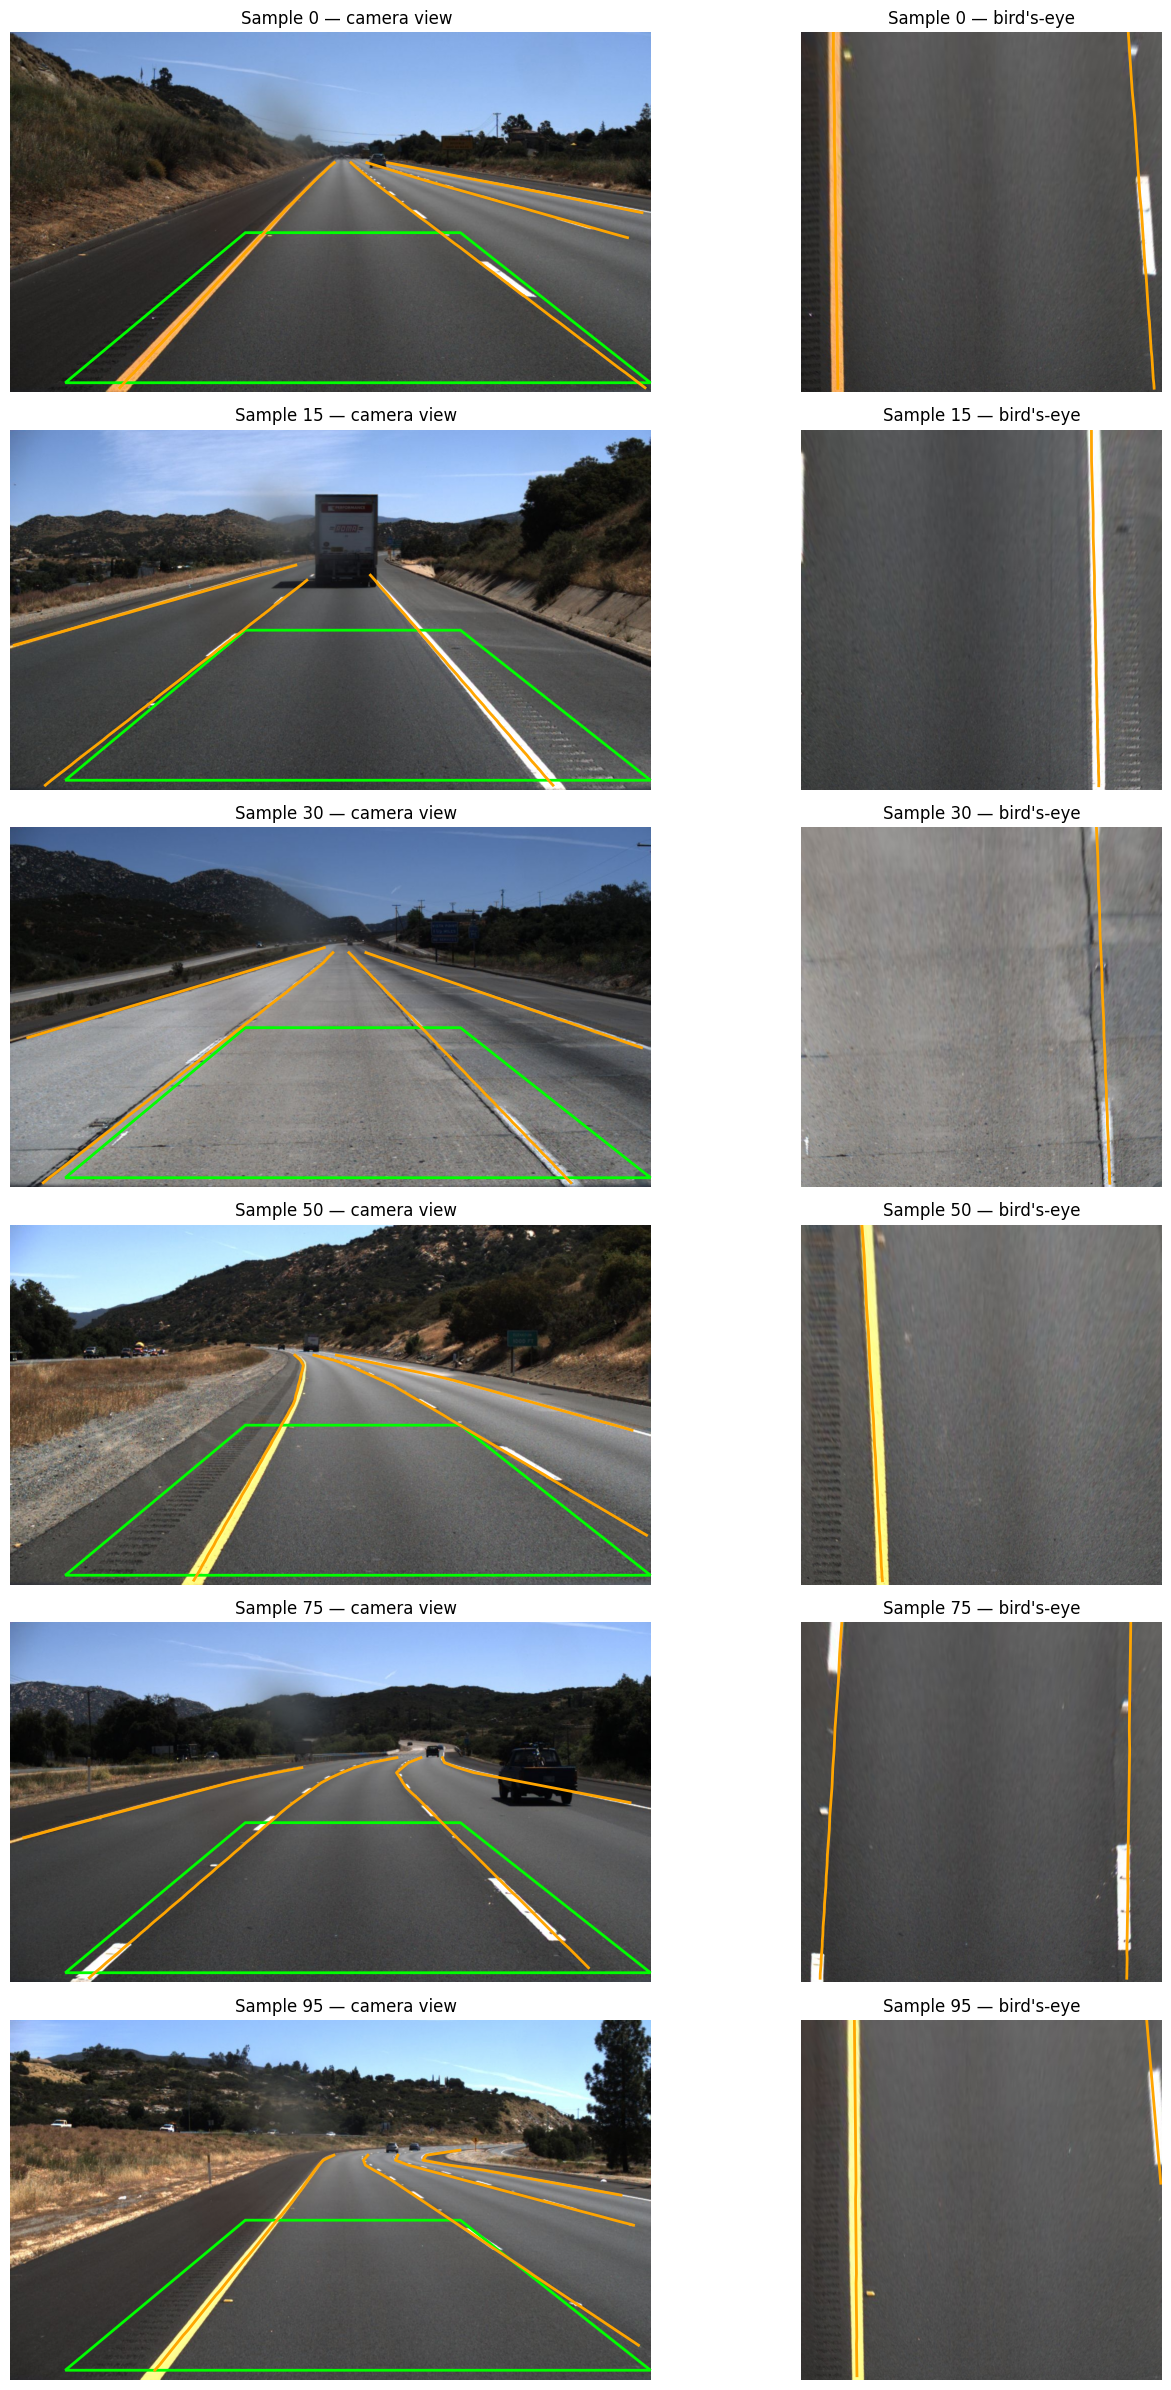

In [ ]:
# Lock in our final values
SRC_PTS = np.float32([
    [470,  400],   # top-left
    [900,  400],   # top-right
    [1280, 700],   # bottom-right
    [110,  700],   # bottom-left
])
DST_SIZE = 720
DST_PTS = np.float32([
    [0,        0],
    [DST_SIZE, 0],
    [DST_SIZE, DST_SIZE],
    [0,        DST_SIZE],
])

M = cv2.getPerspectiveTransform(SRC_PTS, DST_PTS)
M_inv = cv2.getPerspectiveTransform(DST_PTS, SRC_PTS)

# Test on 6 different samples
sample_indices = [0, 15, 30, 50, 75, 95]
fig, axes = plt.subplots(len(sample_indices), 2, figsize=(14, 24))

for row, idx in enumerate(sample_indices):
    test_sample = dataset[idx]
    test_img = cv2.imread(str(test_sample.image_path))
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_warped = cv2.warpPerspective(test_img, M, (DST_SIZE, DST_SIZE))

    # Left: camera view with trapezoid + GT lanes
    axes[row, 0].imshow(test_img)
    trap = MplPolygon(SRC_PTS, closed=True, fill=False,
                      edgecolor="lime", linewidth=2)
    axes[row, 0].add_patch(trap)
    for lane_idx in range(test_sample.num_lanes):
        pts = test_sample.get_lane_points(lane_idx)
        if len(pts) > 1:
            xs, ys = zip(*pts)
            axes[row, 0].plot(xs, ys, "-", color="orange", linewidth=2)
    axes[row, 0].set_title(f"Sample {idx} — camera view")
    axes[row, 0].axis("off")

    # Right: bird's-eye view with warped GT lanes
    axes[row, 1].imshow(test_warped)
    for lane_idx in range(test_sample.num_lanes):
        pts = test_sample.get_lane_points(lane_idx)
        if len(pts) > 1:
            warped_pts = transform_points(np.array(pts), M)
            mask = (
                (warped_pts[:, 0] >= 0) & (warped_pts[:, 0] < DST_SIZE)
                & (warped_pts[:, 1] >= 0) & (warped_pts[:, 1] < DST_SIZE)
            )
            in_frame = warped_pts[mask]
            if len(in_frame) > 1:
                axes[row, 1].plot(in_frame[:, 0], in_frame[:, 1],
                                  "-", color="orange", linewidth=2)
    axes[row, 1].set_title(f"Sample {idx} — bird's-eye")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()